# Notebook2: 

**Goal:** Explore the distribution of key features, compare churners against retained subscribers, and validate behavioural hypotheses with statistical tests.

Dataset: 1,082,190 subscribers. Target: `is_churn`.

## Libraries and setup

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
from lifelines import KaplanMeierFitter

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.3

## Load master dataset

In [41]:
PROCESSED = Path("../data/processed")

master = pd.read_csv(
    PROCESSED / "master.csv",
    parse_dates=['registration_init_time', 'last_active_date']
)

print(f"Shape:      {master.shape[0]:,} rows × {master.shape[1]} columns")
print(f"Churn rate: {master['is_churn'].mean():.2%}")
print(f"\nColumn dtypes:")
print(master.dtypes.value_counts())
print(f"\nNull rates (columns with any nulls):")
null_rates = master.isnull().mean().sort_values(ascending=False)
print(null_rates[null_rates > 0].map(lambda x: f"{x:.1%}"))

Shape:      1,082,190 rows × 25 columns
Churn rate: 9.15%

Column dtypes:
float64           12
int64              7
object             4
datetime64[ns]     2
Name: count, dtype: int64

Null rates (columns with any nulls):
bd                        100.0%
gender                     59.2%
avg_completion_rate        11.7%
first_week_depth           11.7%
days_since_last_active     11.7%
avg_total_secs             11.7%
last_active_date           11.7%
avg_num_unq                11.7%
activity_day_count         11.7%
revenue_per_day            11.2%
tenure_days                11.2%
registration_init_time     11.2%
city                       11.2%
registered_via             11.2%
dtype: object


## Churn distribution — how imbalanced is the dataset?

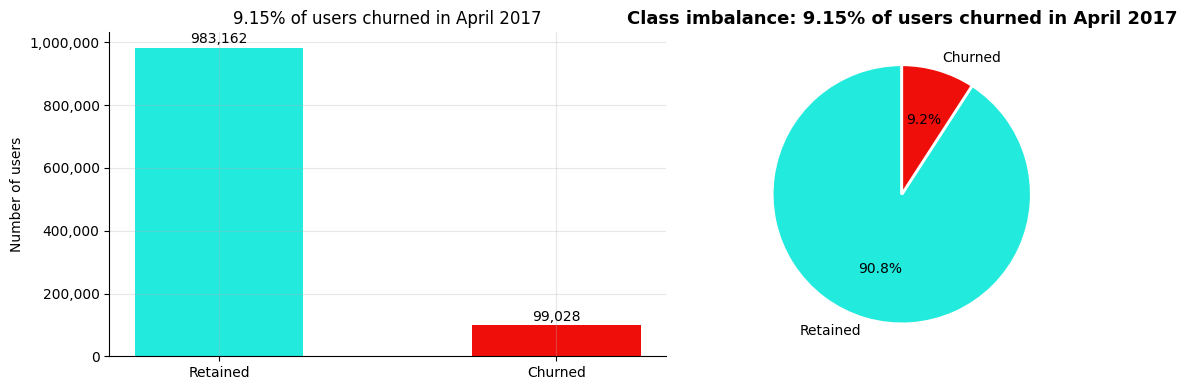

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = master['is_churn'].value_counts().sort_index()
labels = ['Retained', 'Churned']
colors = ["#22eadd", "#f00e0a"]

bars = axes[0].bar(labels, counts.values, color=colors, width=0.5)
axes[0].set_title("9.15% of users churned in April 2017")
axes[0].set_ylabel("Number of users")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'{count:,}', ha='center', va='bottom', fontsize=10)
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90
            ,wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title("Class imbalance: 9.15% of users churned in April 2017",
                  fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Null rates — which subscribers are missing data and does it matter?

In [6]:
no_members = master['city'].isna().sum()
no_logs = master['avg_num_unq'].isna().sum()
both_null = master[master['city'].isna() & master['avg_num_unq'].isna()].shape[0]
print("=== null rates interpretation ===")
print(f"users with no membership record:{no_members} ({no_members/len(master):.1%})")
print(f"users with no listening logs:    {no_logs} ({no_logs/len(master):.1%})")
print(f"users with both data missing:    {both_null} ({both_null/len(master):.1%})")
print(f"\nbd (age) = 100% null dropping")
print(f"gender = 59.2% null - keep")
print(f"\nMissingness is signal: users witn no records are probably tier-free subscribers")
master = master.drop(columns=['bd'])

=== null rates interpretation ===
users with no membership record:120759 (11.2%)
users with no listening logs:    127031 (11.7%)
users with both data missing:    120726 (11.2%)

bd (age) = 100% null dropping
gender = 59.2% null - keep

Missingness is signal: users witn no records are probably tier-free subscribers


## Does gender predict churn?

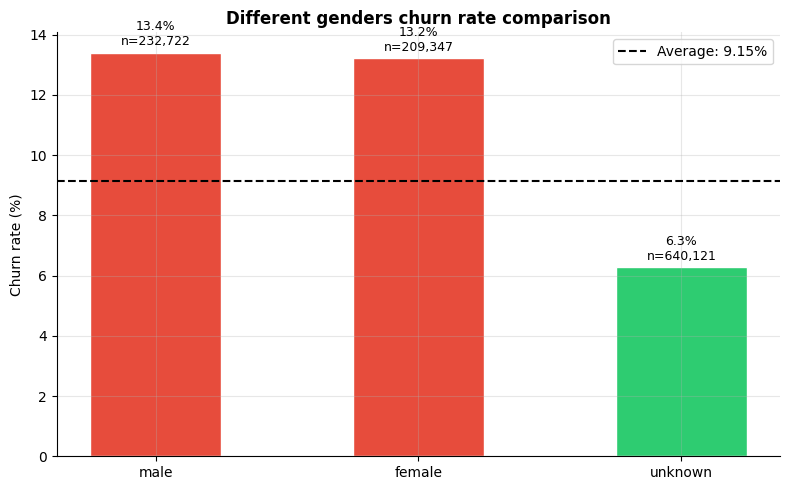

In [7]:
gender_df = (
    master
    .assign(gender_clean=master['gender'].fillna('unknown'))
    .groupby('gender_clean')['is_churn']
    .agg(churn_rate='mean', n_users='count')
    .sort_values('churn_rate', ascending=False)
    .reset_index()
)

avg = master['is_churn'].mean()
colors = ['#e74c3c' if x > avg else '#2ecc71' for x in gender_df['churn_rate']]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(gender_df['gender_clean'], gender_df['churn_rate'] * 100,
              color=colors, width=0.5, edgecolor='white')
ax.axhline(avg * 100, color='black', linestyle='--', linewidth=1.5,
           label=f'Average: {avg:.2%}')
ax.set_title('Different genders churn rate comparison', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('Churn rate (%)')
ax.legend()
for bar, (_, row) in zip(bars, gender_df.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f"{row['churn_rate']:.1%}\nn={row['n_users']:,}",
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Churn rate beetween genders insight
On chart we can see that both Female and Male churn rate is pretty close to each other however both are 2x more likely to churn than unkown gender users 

## Does registration channel predict churn?

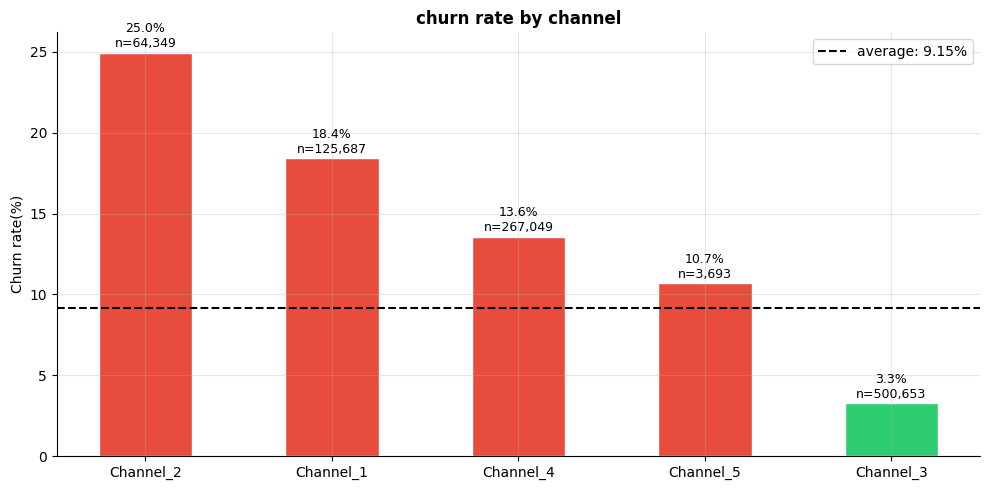

In [8]:
reg_df = (
    master
    .dropna(subset=['registered_via'])
    .assign(channel=master['registered_via'].map({
        3:  'Channel_1',
        4:  'Channel_2',
        7:  'Channel_3',
        9:  'Channel_4',
        13: 'Channel_5'
    }).fillna('Unknown'))
    .groupby('channel')['is_churn']
    .agg(churn_rate='mean', n_users='count')
    .sort_values('churn_rate', ascending=False)
    .reset_index()
)
avg = master['is_churn'].mean()
colors = ['#e74c3c' if x > avg else '#2ecc71' for x in reg_df['churn_rate']]

fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(reg_df['channel'], reg_df['churn_rate'] * 100,
              color=colors, width = 0.5, edgecolor = 'white')
ax.axhline(avg * 100, color = 'black', linestyle='--', linewidth=1.5,
           label=f'average: {avg:.2%}')
ax.set_title('churn rate by channel',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Churn rate(%)')
ax.legend()
for bar, (_, row) in zip(bars, reg_df.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f"{row['churn_rate']:.1%}\nn={row['n_users']:,}",
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()



In [9]:
print(master['registered_via'].value_counts(dropna=False))
print(f"\nUnique values: {master['registered_via'].dropna().unique()}")

registered_via
7.0     500653
9.0     267049
3.0     125687
NaN     120759
4.0      64349
13.0      3693
Name: count, dtype: int64

Unique values: [ 9.  7.  3.  4. 13.]


## Listening behaviour — do churners engage differently?

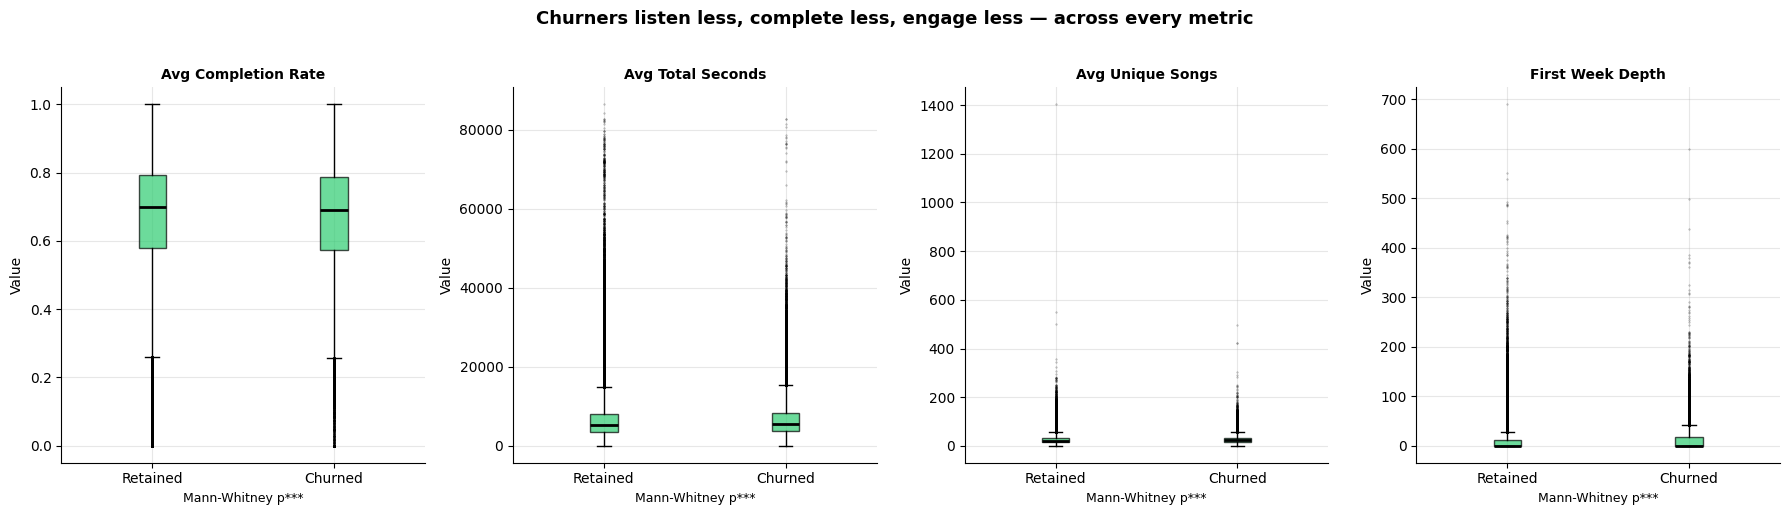

In [10]:
features = ['avg_completion_rate', 'avg_total_secs', 'avg_num_unq', 'first_week_depth']
labels_map = {
    'avg_completion_rate': 'Avg Completion Rate',
    'avg_total_secs':      'Avg Total Seconds',
    'avg_num_unq':         'Avg Unique Songs',
    'first_week_depth':    'First Week Depth'
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, feat in zip(axes, features):
    churned   = master.loc[master['is_churn'] == 1, feat].dropna()
    retained  = master.loc[master['is_churn'] == 0, feat].dropna()

    ax.boxplot(
        [retained, churned],
        labels=['Retained', 'Churned'],
        patch_artist=True,
        boxprops=dict(facecolor='#2ecc71', alpha=0.7),
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='.', markersize=1, alpha=0.3)
    )
    ax.set_title(labels_map[feat], fontsize=10, fontweight='bold')
    ax.set_ylabel('Value')

    stat, p = stats.mannwhitneyu(retained, churned, alternative='two-sided')
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.set_xlabel(f'Mann-Whitney p{sig}', fontsize=9)

fig.suptitle('Churners listen less, complete less, engage less — across every metric',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Median comparison across all numeric features

In [12]:
for feat in ['avg_completion_rate', 'avg_total_secs', 'avg_num_unq', 'first_week_depth']:
    med_ret = master.loc[master['is_churn'] == 0, feat].median()
    med_chu = master.loc[master['is_churn'] == 1, feat].median()
    diff = ((med_ret - med_chu) / med_chu * 100) if med_chu != 0 else float('inf')
    print(f"{feat}:")
    print(f"  Retained median: {med_ret:.2f}")
    print(f"  Churned  median: {med_chu:.2f}")
    print(f"  Retained is {diff:+.1f}% vs churned\n")

avg_completion_rate:
  Retained median: 0.70
  Churned  median: 0.69
  Retained is +1.0% vs churned

avg_total_secs:
  Retained median: 5235.90
  Churned  median: 5601.80
  Retained is -6.5% vs churned

avg_num_unq:
  Retained median: 21.28
  Churned  median: 23.13
  Retained is -8.0% vs churned

first_week_depth:
  Retained median: 0.00
  Churned  median: 0.00
  Retained is +inf% vs churned



## Hypothesis — churners listen to fewer unique tracks

Mann-Whitney U test: are the listening distributions of churners and retained subscribers statistically different?

In [13]:
retained_unq = master.loc[master['is_churn'] == 0, 'avg_num_unq'].dropna()
churned_unq  = master.loc[master['is_churn'] == 1, 'avg_num_unq'].dropna()

stat, p = stats.mannwhitneyu(retained_unq, churned_unq, alternative='two-sided')

n_ret = len(retained_unq)
n_chu = len(churned_unq)
rank_biserial = 1 - (2 * stat) / (n_ret * n_chu)

print(f"Retained median unique songs: {retained_unq.median():.2f}")
print(f"Churned  median unique songs: {churned_unq.median():.2f}")
print(f"Mann-Whitney U: {stat:.0f}")
print(f"P-value: {p:.2e}")
print(f"Rank-biserial correlation: {rank_biserial:.4f}")

Retained median unique songs: 21.28
Churned  median unique songs: 23.13
Mann-Whitney U: 36178493187
P-value: 0.00e+00
Rank-biserial correlation: 0.0855


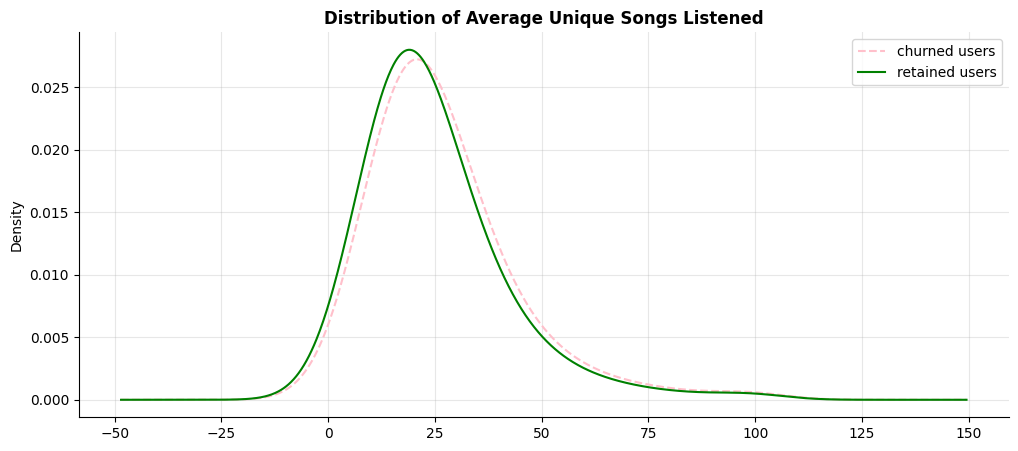

(0.0, 100.0)

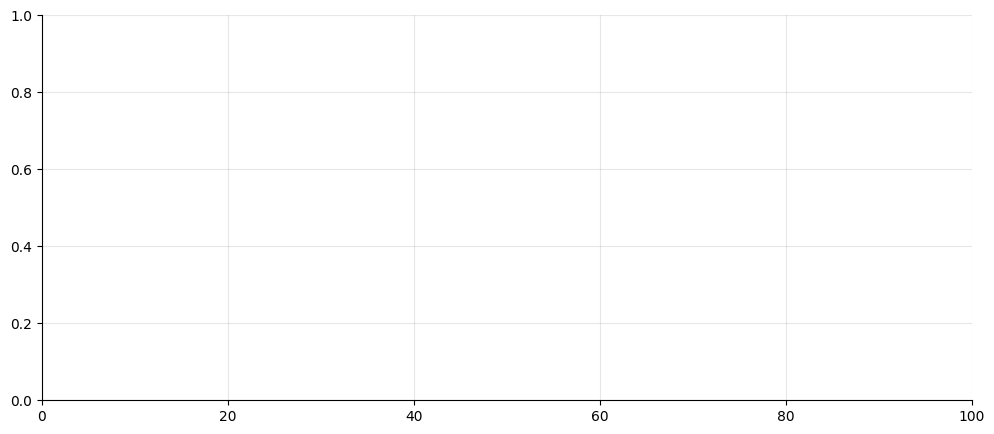

In [14]:
churned_unq.clip(lower=0, upper=100).plot.kde(bw_method=0.5, color = 'pink', linestyle = '--', label = 'churned users')
retained_unq.clip(lower=0, upper=100).plot.kde(bw_method=0.5, color = 'green', label = 'retained users')
plt.title('Distribution of Average Unique Songs Listened', fontsize=12, fontweight='bold')
plt.legend()
plt.show()
plt.xlim(0, 100)

## Feature signal strength — median ratio of churned vs retained

In [15]:
medians = (master.select_dtypes(include='number')
           .groupby('is_churn')
           .median()
           .transpose()
)
medians.columns = ['Retained', 'Churned']
with np.errstate(divide= 'ignore', invalid = 'ignore'):
    medians['diff_pct'] = (
        (medians['Retained'] - medians['Churned'])
        / medians['Churned'].abs()
    ) * 100
    
medians['diff_pct'] = medians['diff_pct'].replace([np.inf, -np.inf], np.nan)
scan = (
    medians.reset_index()
    .rename(columns={'index': 'feature'})
    .sort_values(by='diff_pct', key=np.abs, ascending=False)
    .round(3)
)
print(scan.to_string(index=False, justify='left', col_space=15, max_rows=20))

feature                 Retained        Churned         diff_pct      
             txn_count   18.000           6.000        200.000        
days_since_last_active    2.000          21.000        -90.476        
                  city    1.000           5.000        -80.000        
       revenue_per_day    2.964           2.164         36.956        
    activity_day_count  244.000         198.000         23.232        
            total_paid 2079.000        1788.000         16.275        
           tenure_days 1032.000         911.000         13.282        
           avg_num_unq   21.280          23.130         -7.998        
        avg_total_secs 5235.900        5601.800         -6.532        
   avg_completion_rate    0.698           0.691          0.999        
     avg_plan_duration   30.000          30.000          0.000        
        registered_via    7.000           7.000          0.000        
                has_tx    1.000           1.000          0.000        
      

In [16]:
mean = (master.select_dtypes(include='number')
         .groupby('is_churn')
         .mean()
         .transpose()
)
mean.columns = ['Retained', 'Churned']
with np.errstate(divide= 'ignore', invalid = 'ignore'):
    mean['diff_pct'] = (
        (mean['Retained'] - mean['Churned']) / mean['Churned'].abs()
    )
mean['diff_pct'] = mean['diff_pct'].replace([np.inf, -np.inf], np.nan)
scan_mean = (
    mean.reset_index()
    .rename(columns={'index': 'feature'})
    .sort_values(by='diff_pct', key=np.abs, ascending=False)
    .round(1)
)
print(scan_mean.to_string(index=False, justify='left', col_space=15, max_rows=20))

feature                 Retained        Churned         diff_pct      
    auto_renew_history    0.9             0.4           1.4           
             txn_count   17.0             9.3           0.8           
     avg_plan_duration   31.9            87.3          -0.6           
          cancel_count    0.3             0.5          -0.4           
days_since_last_active   26.7            43.7          -0.4           
                  city    5.8             7.7          -0.2           
      first_week_depth    9.1            11.7          -0.2           
            total_paid 2310.0          1944.9           0.2           
    activity_day_count  294.2           256.7           0.1           
        registered_via    6.9             6.3           0.1           
           avg_num_unq   25.0            27.1          -0.1           
           tenure_days 1293.5          1217.7           0.1           
        avg_total_secs 6545.2          6959.6          -0.1           
      

## Does subscription length predict churn?

In [17]:

bin_edges = [30, 90, 180, 366, 10000]
bin_labels = ['monthly', 'quarterly', 'semi-annual', 'annual', 'more_than_annual']
# ensure number of bin edges = number of labels + 1
bins = [0] + bin_edges
master['subscription_type'] = pd.cut(master['avg_plan_duration'], bins=bins, labels=bin_labels, include_lowest=True)
print(master['subscription_type'].value_counts(dropna=False))

subscription_type
monthly             969530
quarterly            75643
semi-annual          17487
annual               10767
more_than_annual      8763
Name: count, dtype: int64


count    1.082190e+06
mean     3.699554e+01
std      4.237034e+01
min      0.000000e+00
25%      2.896296e+01
50%      3.000000e+01
75%      3.000000e+01
max      4.500000e+02
Name: avg_plan_duration, dtype: float64
avg_plan_duration
410.0    6626
402.5     739
395.0     453
405.0     349
400.0     161
450.0     123
385.0      85
387.5      34
397.5      27
430.0      22
Name: count, dtype: int64


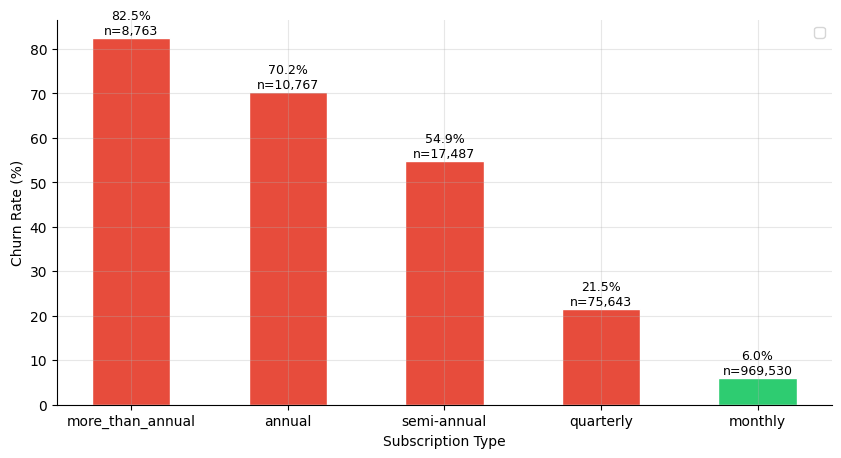

In [18]:
subscription_churn = (
    master
    .groupby('subscription_type')['is_churn']
    .agg(churn_rate='mean', n_users='count')
    .sort_values('churn_rate', ascending=False)
    .reset_index()
)
fig, ax = plt.subplots(figsize=(10, 5))
avg = master['is_churn'].mean()
colors = ['#e74c3c' if x > avg else '#2ecc71' for x in subscription_churn['churn_rate']]
bars = ax.bar(subscription_churn['subscription_type'], subscription_churn['churn_rate']
                * 100, color=colors, width=0.5, edgecolor='white')
ax.set_xlabel('Subscription Type')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
for bar, (_, row) in zip(bars, subscription_churn.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f"{row['churn_rate']:.1%}\nn={row['n_users']:,}",
            ha='center', va='bottom', fontsize=9)
print(master['avg_plan_duration'].describe())
print(master[master['avg_plan_duration'] > 365]['avg_plan_duration'].value_counts().head(10))

Correlation : Users on longer plan will churn more likely than users on shorter plan


## Correlation between numeric features and churn

In [19]:
master.select_dtypes(include='number').columns

Index(['is_churn', 'city', 'registered_via', 'total_paid', 'avg_plan_duration',
       'auto_renew_history', 'cancel_count', 'txn_count', 'activity_day_count',
       'avg_num_unq', 'avg_total_secs', 'avg_completion_rate',
       'first_week_depth', 'has_tx', 'has_logs', 'tenure_days',
       'days_since_last_active', 'revenue_per_day'],
      dtype='object')

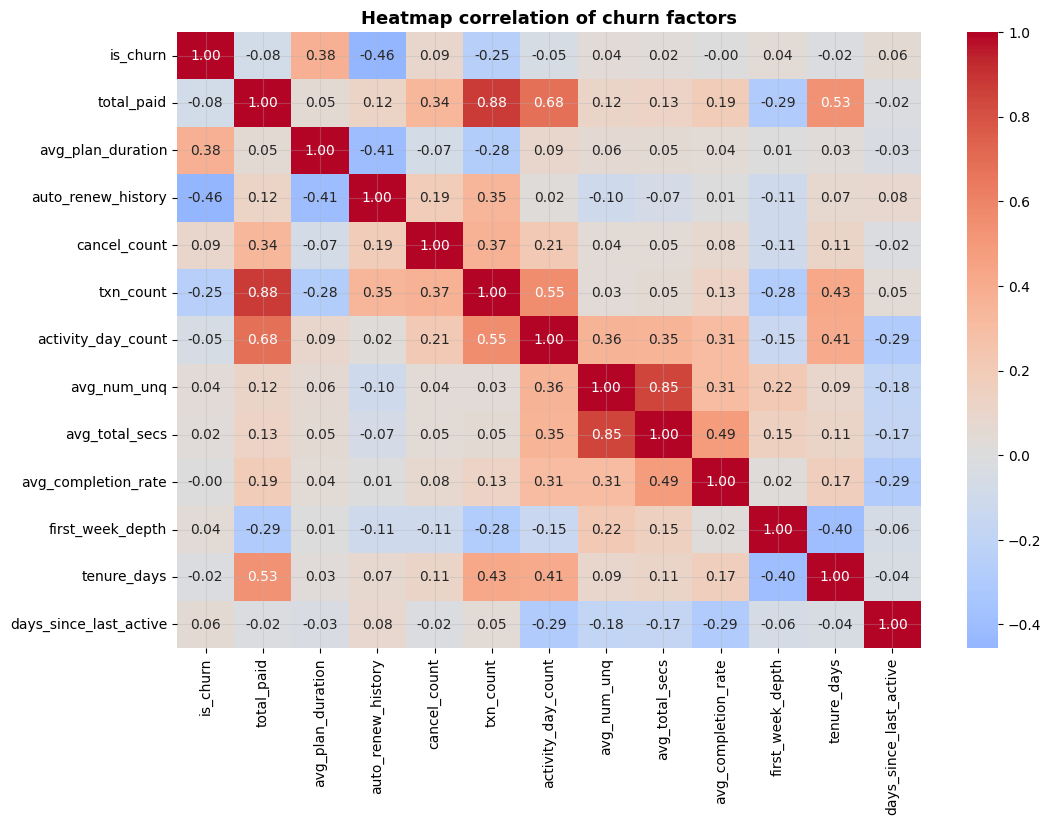

In [20]:
numeric_df = master[['is_churn', 'total_paid', 'avg_plan_duration',
       'auto_renew_history', 'cancel_count', 'txn_count', 'activity_day_count',
       'avg_num_unq', 'avg_total_secs', 'avg_completion_rate',
       'first_week_depth', 'tenure_days',
       'days_since_last_active']]
corr_matrix = numeric_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Heatmap correlation of churn factors', fontsize=13, fontweight='bold')
plt.show()
churn_corr = corr_matrix['is_churn'].sort_values(ascending=False)

## Conclusion

Churners listen less, have shorter plan durations, and lower auto-renew rates. The Mann-Whitney test confirms the listening depth difference is statistically significant (p < 0.001).

Subscription structure — not listening volume — is the sharpest predictor of churn. This finding shapes all feature engineering in notebook 5.

Next: notebook 3 tracks how retention varies across registration cohorts over time.